# Prepared Data Workflow — Interpretable Model Inputs

This notebook turns joined trajectory-metric exports into a cleaned, modelling-ready dataset for the downstream GAM and XGBoost notebooks.<br>
**Workflow summary:** import analysis tools, load the joined CSV, inspect distributions and dependency structure, remove redundant features, decide on target scaling, then export the prepared table.


## 1. Imports and Configuration
**Purpose:** Load the analysis libraries used to inspect feature quality and prepare the final modelling table.<br>
**Inputs:** Python plotting/statistics libraries available in the environment.<br>
**Outputs:** imported utilities ready for the remaining preparation workflow.<br>
**How to Verify:** the import cell should execute without missing-package errors before any dataset-specific assumptions are made.


In [ ]:
# Imports are grouped here so each later section can focus on one verification question
# rather than on package setup details.
# Core libraries
import json

import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib

# Compatibility shim: matplotlib_inline expects RcParams._get in some versions.
if not hasattr(matplotlib.RcParams, "_get"):
    matplotlib.RcParams._get = matplotlib.RcParams.__getitem__

import matplotlib.pyplot as plt
import seaborn as sns

# Distribution checks
from scipy import stats
from scipy.stats import skew

# Preprocessing and evaluation
from sklearn.feature_selection import mutual_info_regression

# Settings
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load and Inspect the Dataset
**Purpose:** Load the joined trajectory-metric CSV, inspect its schema, and identify the candidate target/features before any transformations.<br>
**Inputs:** run-scoped joined metrics CSV path and the expected trajectory-level columns.<br>
**Outputs:** raw dataframe, dataset info, summary statistics, resolved target column, and the initial numerical feature list.<br>
**How to Verify:** confirm the printed run/path, dataset shape, missing-value summary, selected `target_col`, and detected numerical features before proceeding.


In [ ]:
# Keep the input and export paths run-scoped so the prepared dataset can be traced back
# to the exact trajectory-metric export that produced it.
# ── Configure paths ──────────────────────────────────────────────────────────
# Adjust these values to point to your joined eval_epoch CSV.
RUN_NAME = "full_trainval_12ep_1seed"
EVAL_CSV_NAME = "eval_epoch_12.csv"
INCLUDE_MODEL_SETTINGS_AS_FEATURES = False  # Set to True or False before running.
if INCLUDE_MODEL_SETTINGS_AS_FEATURES is None:
    raise ValueError(
        "Set INCLUDE_MODEL_SETTINGS_AS_FEATURES to True or False before running this notebook. "
        "Use False for trajectory/context-only full-trainval fits; use True only when "
        "model settings should be fitted as predictors."
    )
if not isinstance(INCLUDE_MODEL_SETTINGS_AS_FEATURES, bool):
    raise TypeError("INCLUDE_MODEL_SETTINGS_AS_FEATURES must be True or False.")
print(f"Run: {RUN_NAME}")
print(f"Eval CSV: {EVAL_CSV_NAME}")
print(f"Include model settings as features: {INCLUDE_MODEL_SETTINGS_AS_FEATURES}")
CSV_PATH = (
    Path("../../results/trajectory_prediction/trajectory_metrics_joined")
    / RUN_NAME
    / EVAL_CSV_NAME
)

SAVE_DIR = Path("../../results/interpretable_model/") / RUN_NAME / "plots"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Load the dataset
df = pd.read_csv(CSV_PATH)
if "run_name" not in df.columns:
    df.insert(0, "run_name", RUN_NAME)
if "eval_csv_name" not in df.columns:
    insert_at = df.columns.get_loc("run_name") + 1 if "run_name" in df.columns else 0
    df.insert(insert_at, "eval_csv_name", EVAL_CSV_NAME)
# Add per-second normalised features that combine_runs.py would add for combined data,
# so the feature set is consistent whether this notebook runs on a single run or sweep data.
if (
    "heading_change" in df.columns
    and "duration" in df.columns
    and "heading_change_per_sec" not in df.columns
):
    df.insert(
        df.columns.get_loc("heading_change") + 1,
        "heading_change_per_sec",
        df["heading_change"] / df["duration"].replace(0, float("nan")),
    )

# Load the joined metrics once and reuse the same dataframe throughout the notebook so
# every verification plot refers to the same underlying rows.

print(f"Dataset shape: {df.shape}")
print(f"\n{'='*60}")
print("First 5 rows:")
df.head()

In [ ]:
# Inspect schema and missingness before selecting features; otherwise later drops or
# dtype-related failures would hide whether the raw export itself violated assumptions.
# Data types and missing values
print("Dataset Info:")
print(f"{'='*60}")
df.info()
print(f"\n{'='*60}")
print(f"\nMissing values per column:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34392 entries, 0 to 34391
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   run_name                  34392 non-null  object 
 1   data_idx                  34392 non-null  int64  
 2   ml_ade                    34392 non-null  float64
 3   ml_fde                    34392 non-null  float64
 4   min_ade_5                 34392 non-null  float64
 5   nll_mean                  34392 non-null  float64
 6   nll_final                 34392 non-null  float64
 7   mean_speed                34392 non-null  float64
 8   max_speed                 34392 non-null  float64
 9   std_speed                 34392 non-null  float64
 10  mean_acceleration         34392 non-null  float64
 11  max_acceleration          34392 non-null  float64
 12  mean_jerk                 34392 non-null  float64
 13  max_jerk                  34392 non-null  float

In [4]:
# Summary statistics
print("Summary Statistics:")
df.describe()

Summary Statistics:


,data_idx,ml_ade,ml_fde,min_ade_5,nll_mean,nll_final,mean_speed,max_speed,std_speed,mean_acceleration,...,scene_bbox_area,scene_bbox_width,scene_bbox_height,scene_spatial_density,scene_density_VEHICLE,scene_density_PEDESTRIAN,scene_num_MOTORCYCLE,scene_density_MOTORCYCLE,scene_num_BICYCLE,scene_density_BICYCLE
count,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,...,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,26113.000000,17437.000000,17437.000000,3285.000000,3285.000000
mean,1027.574494,0.414842,0.859655,0.359518,-0.668377,1.287563,0.569993,0.823579,0.146677,-0.001380,...,2084.033393,45.729611,36.607581,0.038241,0.023250,0.017038,5.147904,0.003938,1.315677,0.000611
std,664.617218,1.075039,2.469260,1.013109,2.596503,2.702779,1.110269,1.516328,0.344573,0.166690,...,1813.391294,27.925873,18.501468,0.128424,0.114376,0.046627,3.032908,0.005011,0.464856,0.001400
min,0.000000,0.000489,0.000068,0.000297,-5.451028,-3.274810,0.000000,0.000000,0.000000,-2.090696,...,1.243233,0.174360,5.985279,0.007103,0.001925,0.000221,1.000000,0.000137,1.000000,0.000137
25%,477.000000,0.030745,0.059668,0.019438,-2.389721,-0.378881,0.035016,0.078000,0.017087,-0.009825,...,405.358637,20.420317,20.510335,0.013989,0.007200,0.004031,1.000000,0.000532,1.000000,0.000241
50%,955.000000,0.123354,0.215450,0.093279,-0.823217,0.925104,0.084085,0.219973,0.056765,0.000000,...,1649.316744,43.828089,36.249947,0.017471,0.011983,0.005725,6.000000,0.002010,1.000000,0.000252
75%,1494.000000,0.334069,0.586462,0.253248,0.528869,2.259896,0.955389,1.277989,0.120839,0.011298,...,3566.605359,64.252107,51.220052,0.029033,0.017073,0.011658,8.000000,0.004739,2.000000,0.000491
max,2768.000000,14.711194,31.113197,14.354764,20.000000,20.000000,9.833902,12.098381,3.149516,1.610515,...,7320.339223,101.792308,74.781967,1.608709,1.514852,0.804354,8.000000,0.025200,2.000000,0.010867


In [ ]:
# Resolve the target and candidate numerical features explicitly so later pruning and
# transformation steps can be verified against a fixed starting point.
# ── Define target and feature columns ─────────────────────────────────────────
# Target: trajectory prediction error metric
target_col = "ml_ade"  # Change to 'ml_fde', 'min_ade_5', etc. as needed

# Auto-detect from common target names if not found
potential_targets = [
    "ml_ade",
    "ml_fde",
    "min_ade_5",
    "min_fde_5",
    "ade",
    "fde",
    "minADE",
    "minFDE",
    "min_ade",
    "min_fde",
    "brier_fde",
    "nll",
    "miss_rate",
]
if target_col not in df.columns:
    for col in potential_targets:
        if col in df.columns:
            target_col = col
            break

assert (
    target_col in df.columns
), f"Target '{target_col}' not found. Available: {df.columns.tolist()}"
print(f"Target variable: {target_col}")

# Agent motion & scene context features
FEATURE_CANDIDATES = [
    # Agent motion features
    "mean_speed",
    "max_speed",
    "std_speed",
    "mean_acceleration",
    "max_acceleration",
    "mean_jerk",
    "max_jerk",
    # path_efficiency (displacement/path_length) is window-independent;
    # displacement and path_length are omitted — their scale information
    # is already captured by mean_speed.
    "path_efficiency",
    "heading_change",
    "has_collision",
    "min_neighbor_distance",
    # Per-second normalised variant: heading_change_per_sec gives angular rate
    # (deg/s), comparable across runs with different window lengths.
    # displacement and path_length are left unnormalised — they scale with
    # window length similarly to ADE, preserving the feature→target relationship.
    "heading_change_per_sec",
    # Scene context features
    "scene_num_agents",
    "scene_num_VEHICLE",
    "scene_bbox_area",
    "scene_bbox_width",
    "scene_bbox_height",
    "scene_spatial_density",
    "scene_density_VEHICLE",
]

# Model-setting columns: constant within a run, carried as metadata through the
# pipeline so downstream notebooks can filter or group by configuration.
MODEL_SETTING_COLS = ["attention_radius_m", "history_sec", "prediction_sec"]

# Keep only features that actually exist in the data
numerical_cols = [
    c
    for c in FEATURE_CANDIDATES
    if c in df.columns and np.issubdtype(df[c].dtype, np.number)
]
model_setting_cols = [c for c in MODEL_SETTING_COLS if c in df.columns]
model_setting_feature_cols = (
    list(model_setting_cols) if INCLUDE_MODEL_SETTINGS_AS_FEATURES else []
)
model_setting_metadata_cols = (
    [] if INCLUDE_MODEL_SETTINGS_AS_FEATURES else list(model_setting_cols)
)

# Identify any categorical columns among the features (e.g., agent type)
categorical_cols = [
    c for c in df.columns if df[c].dtype == "object" or df[c].dtype.name == "category"
]
# Exclude ID-like columns
exclude_patterns = ["instance", "id", "idx", "name"]
categorical_cols = [
    c for c in categorical_cols if not any(p in c.lower() for p in exclude_patterns)
]

print(f"\nNumerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Model setting cols ({len(model_setting_cols)}): {model_setting_cols}")
print(f"Model setting feature cols: {model_setting_feature_cols}")
print(f"Model setting metadata cols: {model_setting_metadata_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

## 3. Check Distribution of Features and Target
**Purpose:** Assess marginal distributions and skewness so later transformation decisions are grounded in observed data shape.<br>
**Inputs:** raw dataframe, selected target column, and detected numerical feature columns.<br>
**Outputs:** target distribution plots, feature distribution grids, and a skewness summary table.<br>
**How to Verify:** confirm the target histogram/KDE and skewness table agree about whether the target is strongly right-skewed.


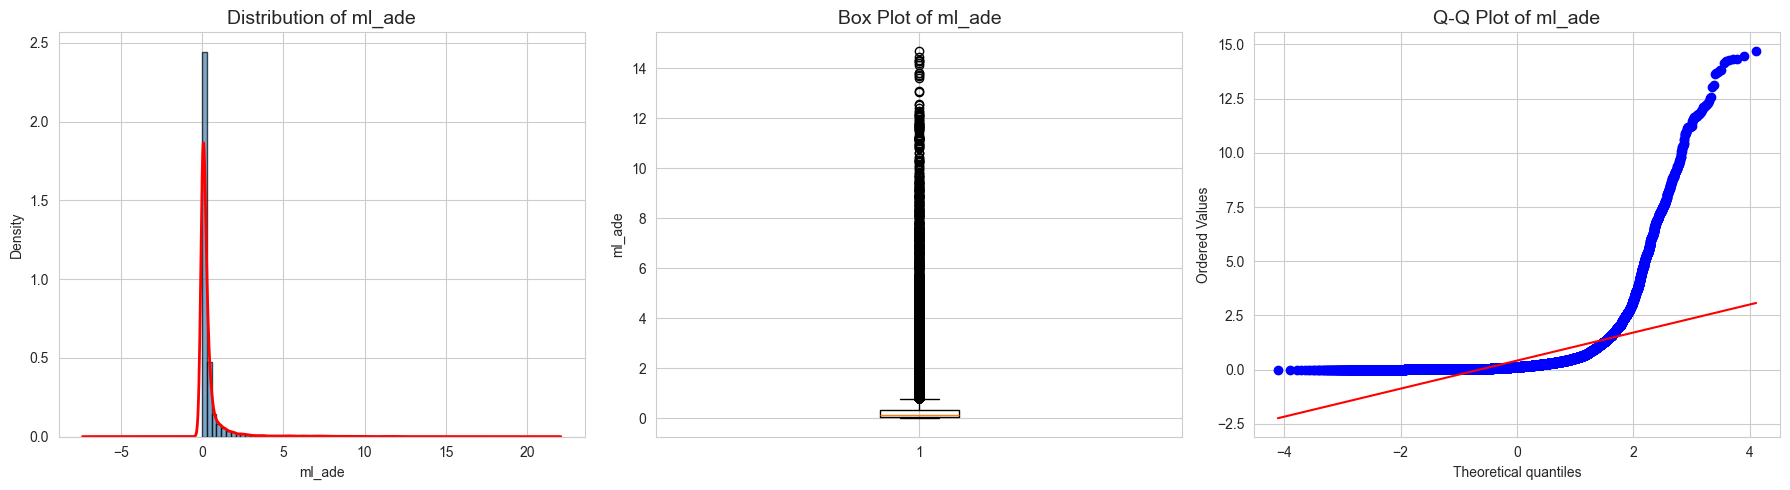


Target 'ml_ade' statistics:
  Skewness:  6.3386
  Kurtosis:  50.1827
  → Target is RIGHT-SKEWED (skewness > 1). Log transformation recommended.
    (Common for ADE/FDE — error distributions are typically right-skewed)


In [ ]:
# Distribution of the target variable (prediction error metric)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram + KDE
axes[0].hist(
    df[target_col].dropna(),
    bins=50,
    density=True,
    alpha=0.7,
    color="steelblue",
    edgecolor="black",
)
df[target_col].dropna().plot.kde(ax=axes[0], color="red", linewidth=2)
axes[0].set_title(f"Distribution of {target_col}", fontsize=14)
axes[0].set_xlabel(target_col)
axes[0].set_ylabel("Density")

# Box plot
axes[1].boxplot(df[target_col].dropna(), vert=True)
axes[1].set_title(f"Box Plot of {target_col}", fontsize=14)
axes[1].set_ylabel(target_col)

# Q-Q plot
stats.probplot(df[target_col].dropna(), dist="norm", plot=axes[2])
axes[2].set_title(f"Q-Q Plot of {target_col}", fontsize=14)

plt.tight_layout()
plt.savefig(
    SAVE_DIR / f"target_distribution_{target_col}.png", dpi=150, bbox_inches="tight"
)
plt.show()

# Skewness and kurtosis
target_skewness = skew(df[target_col].dropna())
target_kurtosis = stats.kurtosis(df[target_col].dropna())
print(f"\nTarget '{target_col}' statistics:")
print(f"  Skewness:  {target_skewness:.4f}")
print(f"  Kurtosis:  {target_kurtosis:.4f}")

if target_skewness > 1:
    print(f"  → Target is RIGHT-SKEWED (skewness > 1). Log transformation recommended.")
    print(f"    (Common for ADE/FDE — error distributions are typically right-skewed)")
elif target_skewness > 0.5:
    print(f"  → Target is MODERATELY right-skewed.")
else:
    print(f"  → Target is approximately symmetric.")

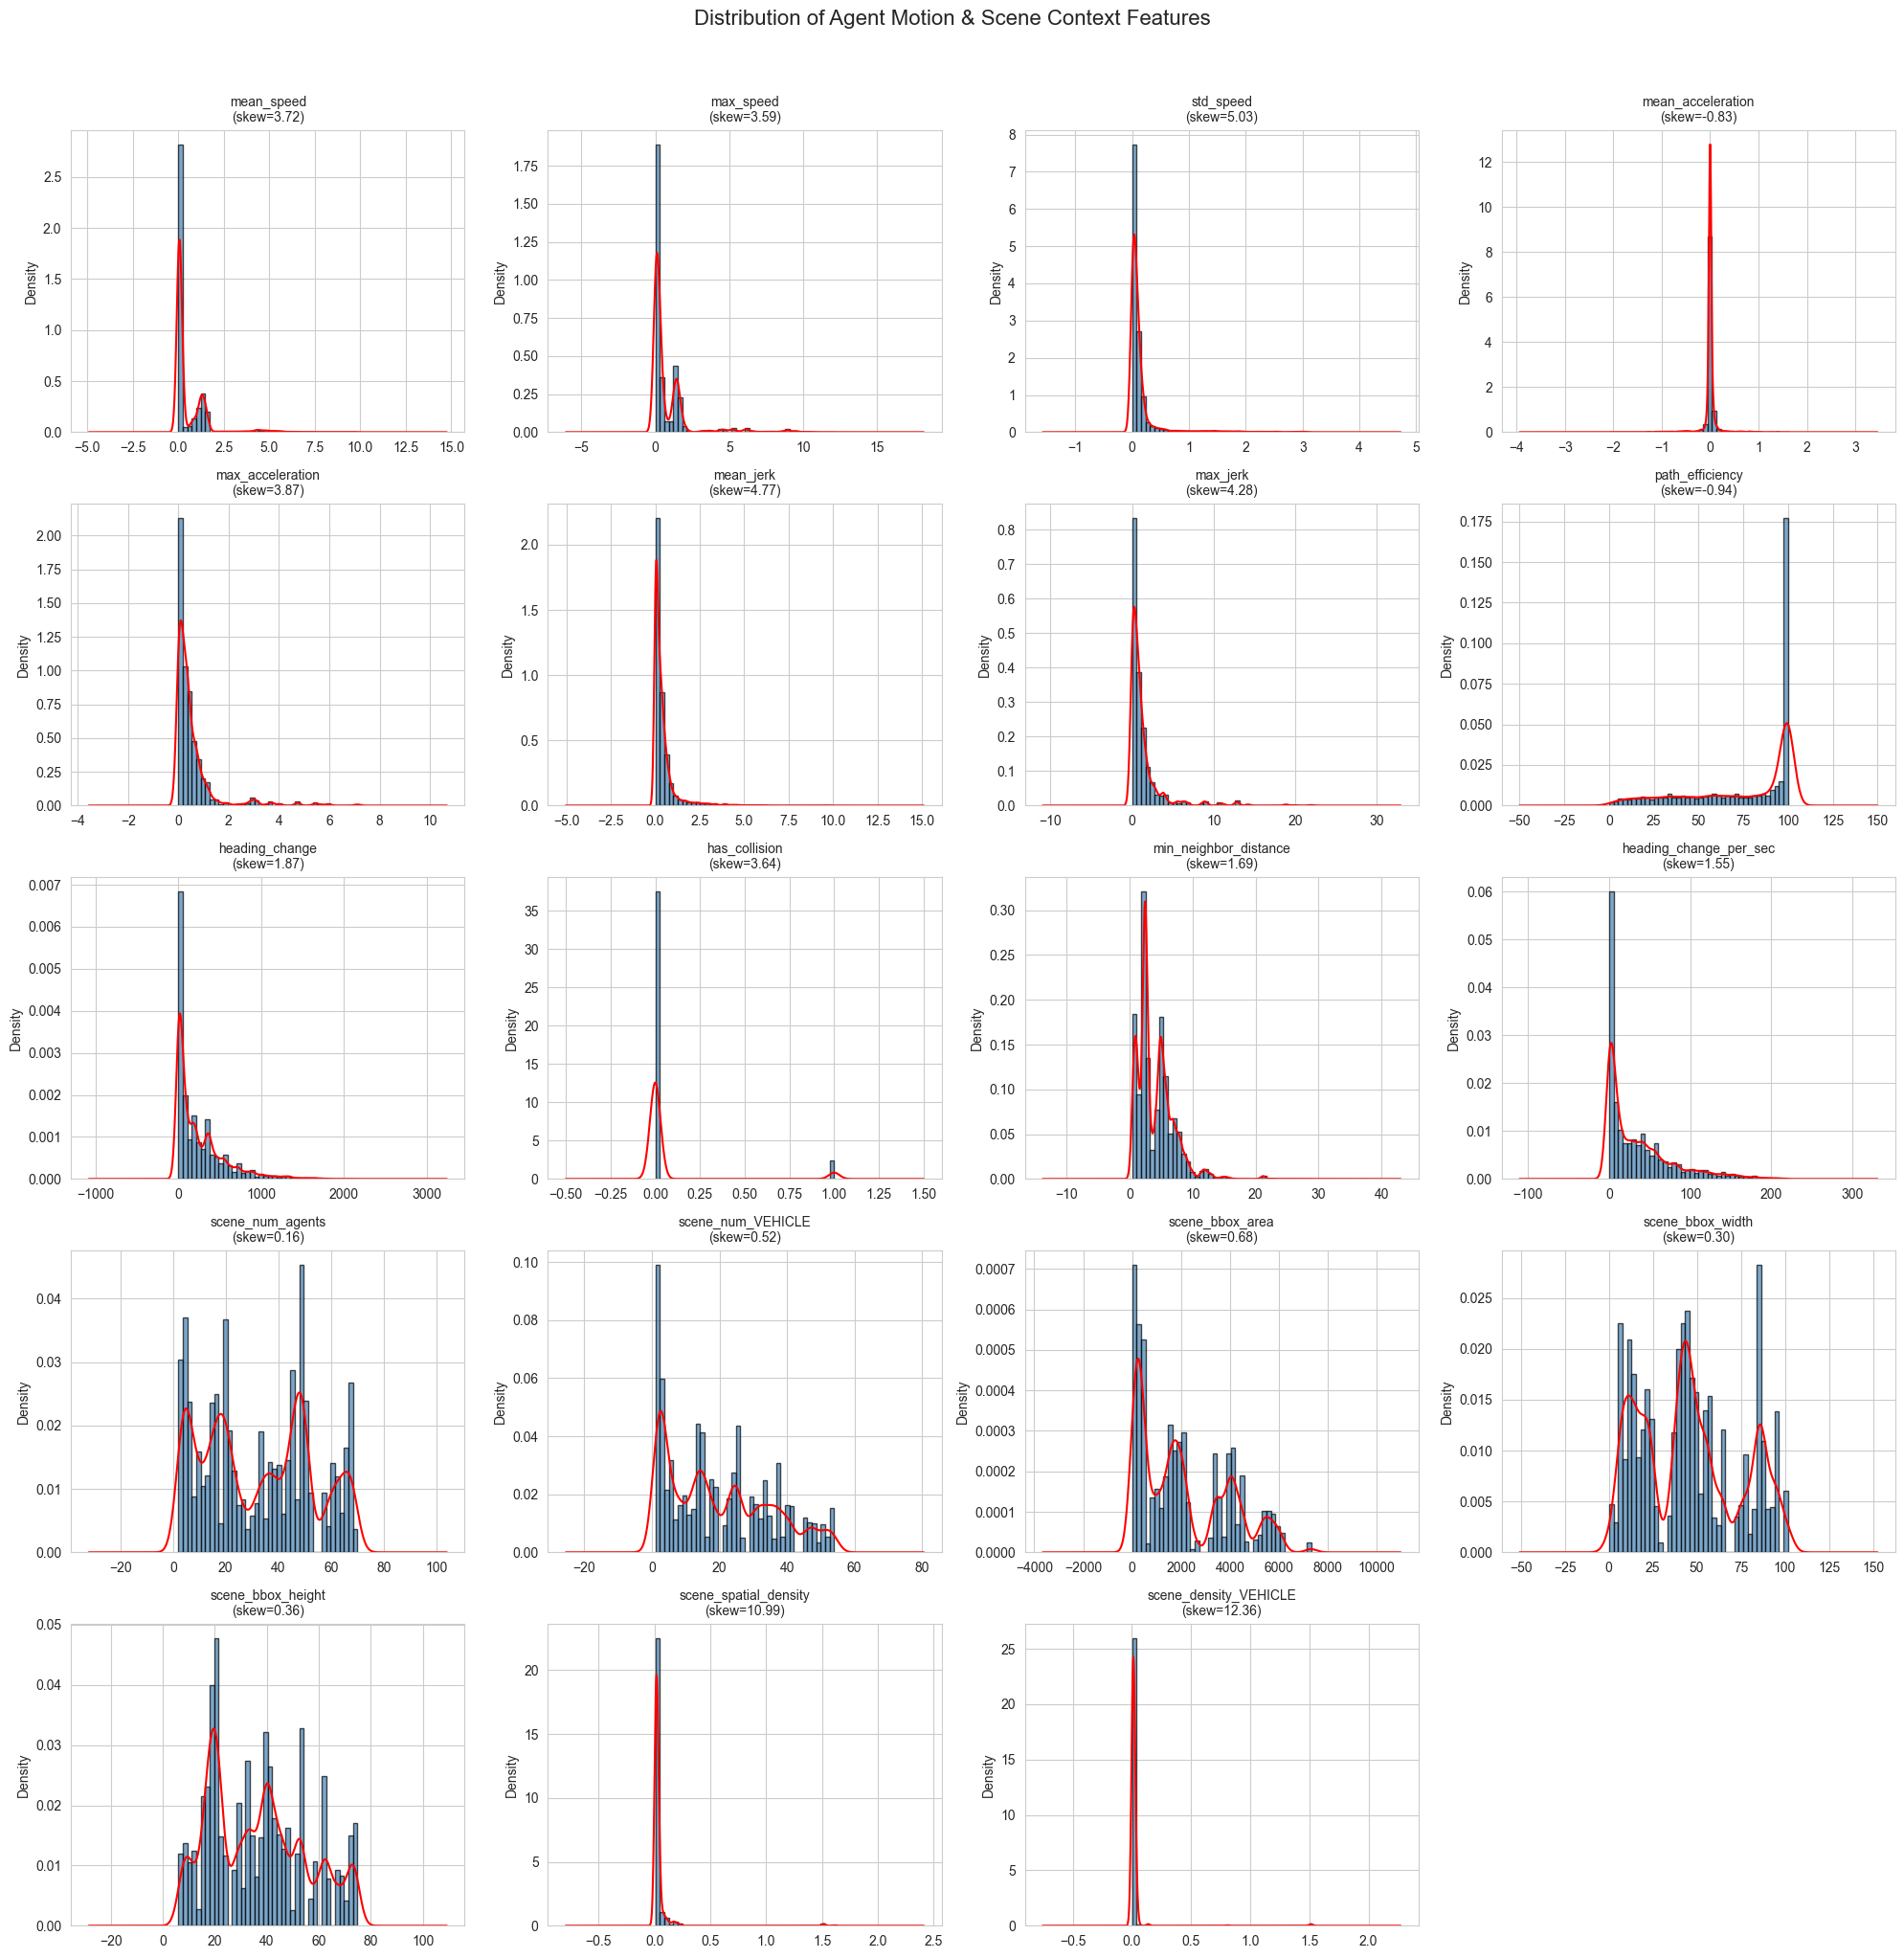

In [ ]:
# Distribution of all numerical features
n_features = len(numerical_cols)
n_cols_plot = 4
n_rows_plot = int(np.ceil(n_features / n_cols_plot))

fig, axes = plt.subplots(
    n_rows_plot, n_cols_plot, figsize=(5 * n_cols_plot, 4 * n_rows_plot)
)
axes = axes.flatten() if n_features > 1 else [axes]

for i, col in enumerate(numerical_cols):
    axes[i].hist(
        df[col].dropna(),
        bins=40,
        density=True,
        alpha=0.7,
        color="steelblue",
        edgecolor="black",
    )
    df[col].dropna().plot.kde(ax=axes[i], color="red", linewidth=1.5)
    col_skew = skew(df[col].dropna())
    axes[i].set_title(f"{col}\n(skew={col_skew:.2f})", fontsize=10)
    axes[i].set_xlabel("")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Distribution of Agent Motion & Scene Context Features", fontsize=16, y=1.02
)
plt.tight_layout()
plt.savefig(SAVE_DIR / "feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Skewness summary table for all features and the target
skewness_df = pd.DataFrame(
    {
        "Feature": numerical_cols + [target_col],
        "Skewness": [skew(df[c].dropna()) for c in numerical_cols + [target_col]],
        "Kurtosis": [
            stats.kurtosis(df[c].dropna()) for c in numerical_cols + [target_col]
        ],
    }
)
skewness_df["Skew Category"] = skewness_df["Skewness"].apply(
    lambda x: (
        "Right-skewed"
        if x > 1
        else ("Moderate" if x > 0.5 else ("Left-skewed" if x < -1 else "Symmetric"))
    )
)
skewness_df = skewness_df.sort_values("Skewness", ascending=False).reset_index(
    drop=True
)
print("Skewness Summary:")
skewness_df

Skewness Summary:


,Feature,Skewness,Kurtosis,Skew Category
0,scene_density_VEHICLE,12.361202,155.115262,Right-skewed
1,scene_spatial_density,10.985938,125.020197,Right-skewed
2,ml_ade,6.338568,50.182671,Right-skewed
3,std_speed,5.029345,28.769131,Right-skewed
4,mean_jerk,4.771773,32.822134,Right-skewed
5,max_jerk,4.281387,23.269801,Right-skewed
6,max_acceleration,3.871843,17.668455,Right-skewed
7,mean_speed,3.717245,17.715307,Right-skewed
8,has_collision,3.644272,11.280718,Right-skewed
9,max_speed,3.588775,14.670265,Right-skewed


## 4. Static Trajectories Analysis
**Purpose:** Quantify how much of the dataset corresponds to stationary agents because that can explain extreme or degenerate metric behavior.<br>
**Inputs:** raw dataframe and the `mean_speed` column.<br>
**Outputs:** a static-agent indicator and summary counts/percentages for static trajectories.<br>
**How to Verify:** confirm `mean_speed` exists and that the reported static percentage is plausible for the selected run.


Static trajectory analysis (mean_speed == 0.0):
  Total trajectories: 34392
  Static:             3555 (10.3%)
  Moving:             30837 (89.7%)


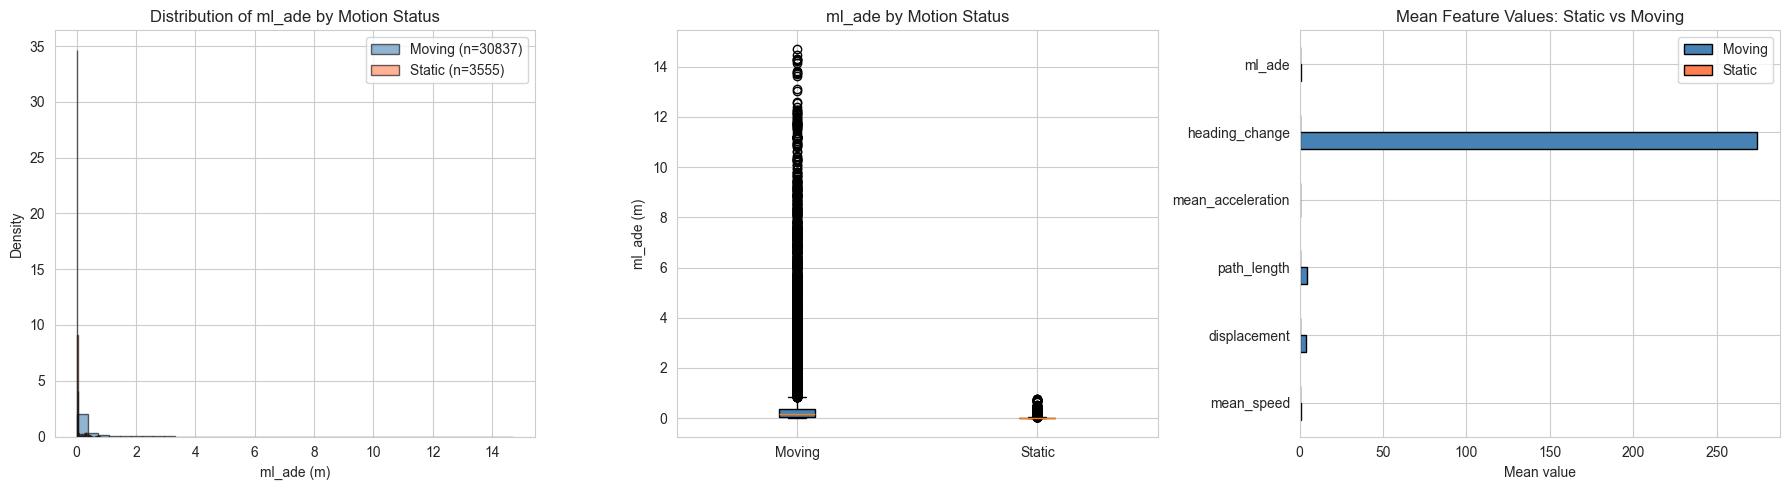


ml_ade summary by motion status:
             count    mean     std     min     25%     50%     75%      max
is_static                                                                  
0          30837.0  0.4586  1.1268  0.0009  0.0463  0.1494  0.3706  14.7112
1           3555.0  0.0355  0.0817  0.0005  0.0068  0.0153  0.0250   0.7765

All feature means by motion status:


,Moving,Static,Ratio (Moving/Static)
mean_speed,0.6357,0.0000,NaN
max_speed,0.9185,0.0000,NaN
std_speed,0.1636,0.0000,NaN
mean_acceleration,-0.0015,0.0000,NaN
max_acceleration,0.6002,0.0000,NaN
mean_jerk,0.4591,0.0000,NaN
max_jerk,1.4791,0.0000,NaN
path_efficiency,72.6361,100.0000,0.7264
heading_change,274.2847,0.0000,NaN
has_collision,0.0655,0.0287,2.2819


In [ ]:
# A zero-speed threshold is intentional here: the goal is to count truly stationary
# trajectories, not merely slow-moving ones that still express motion dynamics.
# ── Static trajectory analysis ───────────────────────────────────────────────
# Identify static agents (mean_speed == 0, i.e., parked/stationary vehicles)
STATIC_SPEED_THRESHOLD = 0.0  # exactly zero

if "mean_speed" in df.columns:
    df["is_static"] = (df["mean_speed"] <= STATIC_SPEED_THRESHOLD).astype(int)
else:
    raise ValueError("'mean_speed' column not found — cannot determine static agents.")

n_static = df["is_static"].sum()
n_moving = len(df) - n_static
pct_static = 100 * n_static / len(df)

print(f"Static trajectory analysis (mean_speed == {STATIC_SPEED_THRESHOLD}):")
print(f"  Total trajectories: {len(df)}")
print(f"  Static:             {n_static} ({pct_static:.1f}%)")
print(f"  Moving:             {n_moving} ({100 - pct_static:.1f}%)")

# ── Compare prediction error: static vs moving ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Overlaid histograms
for label, mask, color in [
    ("Moving", df["is_static"] == 0, "steelblue"),
    ("Static", df["is_static"] == 1, "coral"),
]:
    subset = df.loc[mask, target_col].dropna()
    if len(subset) > 0:
        axes[0].hist(
            subset,
            bins=40,
            density=True,
            alpha=0.6,
            color=color,
            edgecolor="black",
            label=f"{label} (n={len(subset)})",
        )
axes[0].set_xlabel(f"{target_col} (m)")
axes[0].set_ylabel("Density")
axes[0].set_title(f"Distribution of {target_col} by Motion Status")
axes[0].legend()

# 2. Box plot comparison
static_groups = [
    df.loc[df["is_static"] == 0, target_col].dropna(),
    df.loc[df["is_static"] == 1, target_col].dropna(),
]
bp = axes[1].boxplot(static_groups, labels=["Moving", "Static"], patch_artist=True)
bp["boxes"][0].set_facecolor("steelblue")
if len(bp["boxes"]) > 1:
    bp["boxes"][1].set_facecolor("coral")
axes[1].set_ylabel(f"{target_col} (m)")
axes[1].set_title(f"{target_col} by Motion Status")

# 3. Summary bar chart of key features (mean values)
feature_compare_cols = [
    c
    for c in [
        "mean_speed",
        "displacement",
        "path_length",
        "mean_acceleration",
        "heading_change",
        target_col,
    ]
    if c in df.columns
]
summary = df.groupby("is_static")[feature_compare_cols].mean().T
summary.columns = ["Moving", "Static"]
summary.plot(kind="barh", ax=axes[2], color=["steelblue", "coral"], edgecolor="black")
axes[2].set_title("Mean Feature Values: Static vs Moving")
axes[2].set_xlabel("Mean value")

plt.tight_layout()
plt.savefig(SAVE_DIR / "static_vs_moving_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Detailed statistics ──────────────────────────────────────────────────────
print(f"\n{target_col} summary by motion status:")
print(df.groupby("is_static")[target_col].describe().round(4).to_string())

print(f"\nAll feature means by motion status:")
feature_summary = df.groupby("is_static")[numerical_cols + [target_col]].mean().T
feature_summary.columns = ["Moving", "Static"]
feature_summary["Ratio (Moving/Static)"] = feature_summary["Moving"] / feature_summary[
    "Static"
].replace(0, np.nan)
display(feature_summary.round(4))

# ── Recommendation ───────────────────────────────────────────────────────────
if pct_static > 15:
    print(f"\n⚠️  Static agents make up {pct_static:.0f}% of the data.")
    print("  Consider:")
    print("  (a) Filter to moving-only for the primary GAM analysis")
    print("  (b) Add 'is_static' as a factor term f() in the GAM")
    print("  (c) Fit separate GAMs for static vs. moving agents")
elif pct_static == 0:
    print("\n✓ No static agents found in the dataset.")

## 5. Correlation Analysis (Linear and Non-Linear)
**Purpose:** Understand which features are linearly or non-linearly associated with the target before pruning redundant predictors.<br>
**Inputs:** numerical feature columns and the selected target column.<br>
**Outputs:** Pearson/Spearman correlation views, target-correlation comparisons, and mutual-information rankings.<br>
**How to Verify:** cross-check whether the most important-looking features remain consistently strong across Pearson, Spearman, and mutual information.


Variables in correlation analysis (19):
  • mean_speed
  • max_speed
  • std_speed
  • mean_acceleration
  • max_acceleration
  • mean_jerk
  • max_jerk
  • path_efficiency
  • heading_change
  • has_collision
  • min_neighbor_distance
  • heading_change_per_sec
  • scene_num_agents
  • scene_num_VEHICLE
  • scene_bbox_area
  • scene_bbox_width
  • scene_bbox_height
  • scene_spatial_density
  • scene_density_VEHICLE

Excluded (model settings — shown separately in target-correlation chart):
  – attention_radius_m
  – history_sec
  – prediction_sec


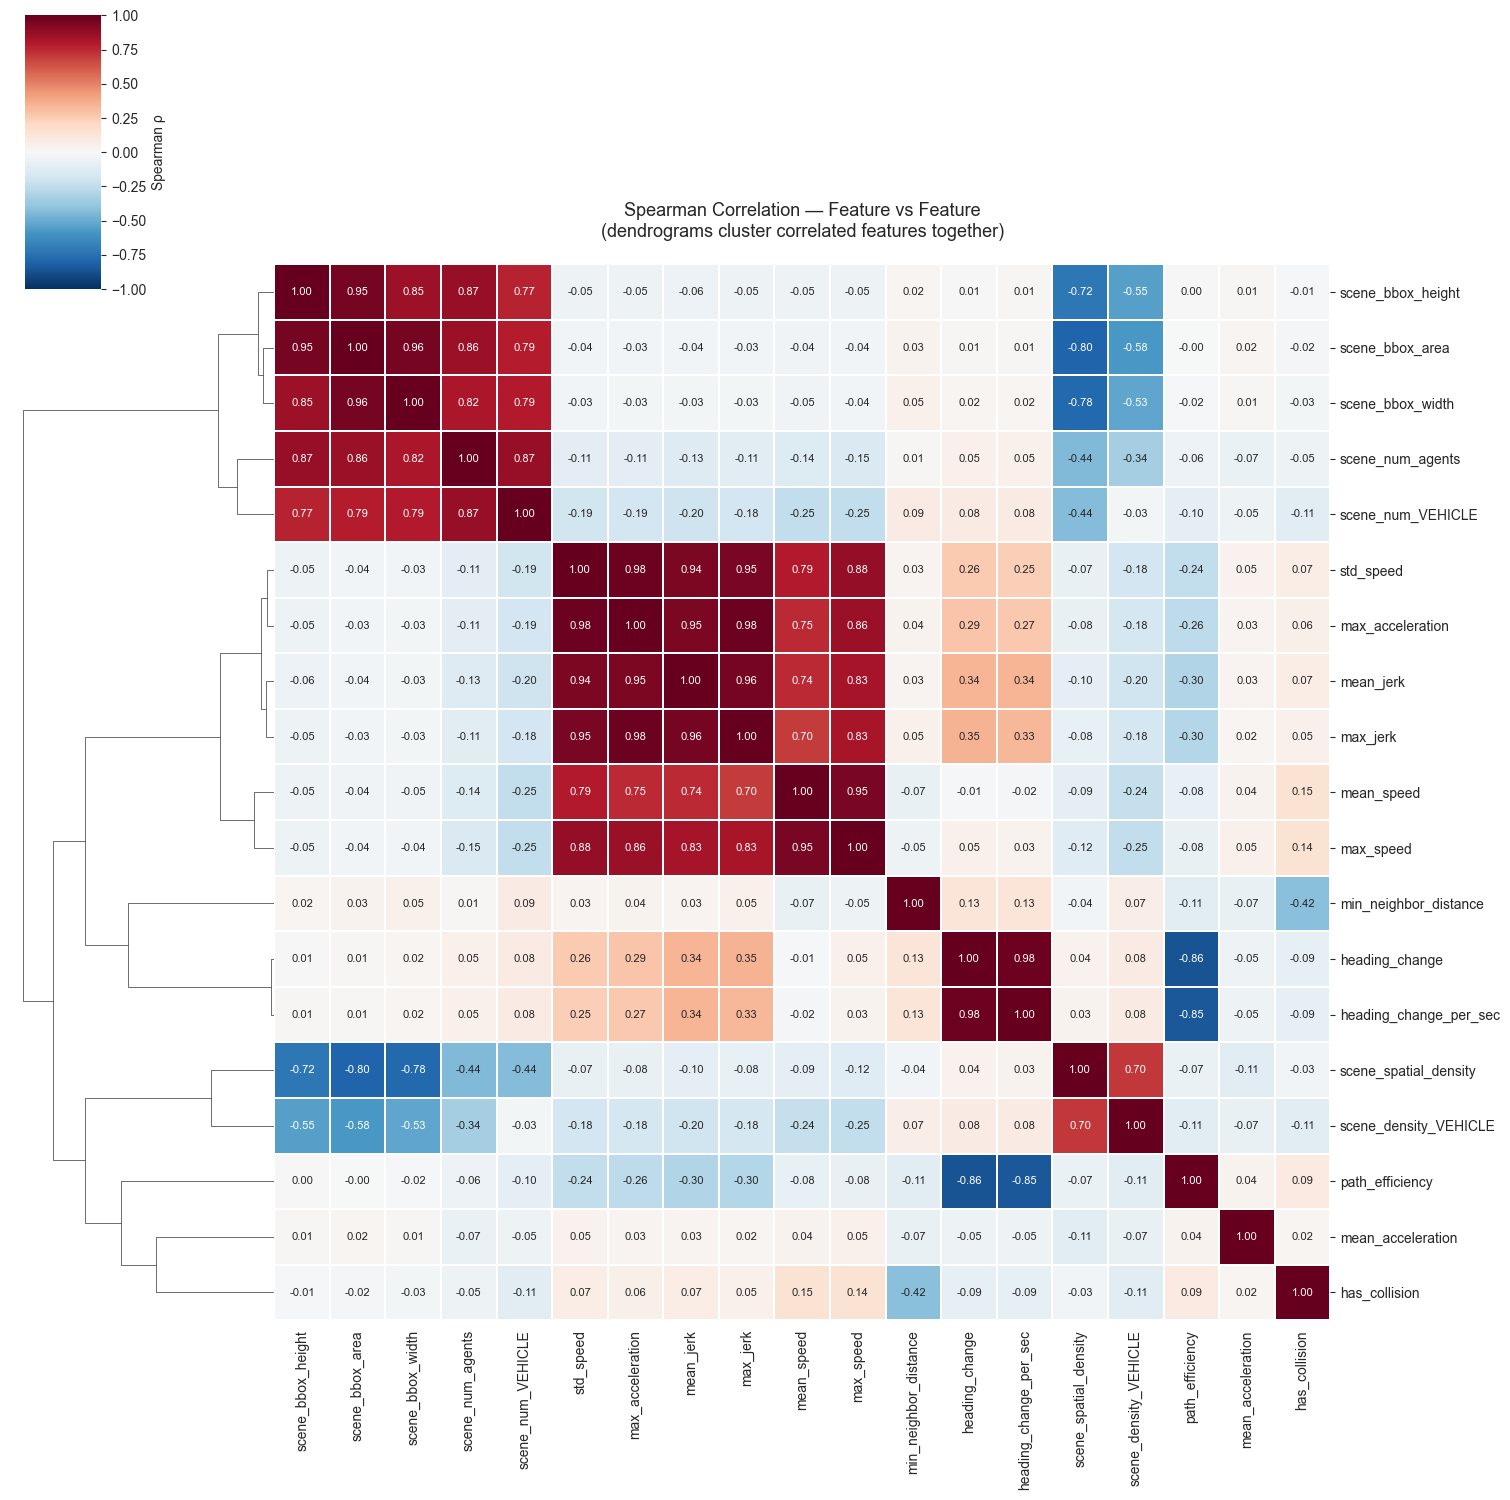

In [ ]:
# ── What is in this correlation section ──────────────────────────────────────
# Included: all 19 FEATURE_CANDIDATES that exist in the data (numerical_cols)
# Excluded from feature-feature plot: model-setting cols (attention_radius_m,
#   history_sec, prediction_sec) — they are run-level metadata, not motion
#   features. They appear in the TARGET correlation bar chart below (Cell 16).
print(f"Variables in correlation analysis ({len(numerical_cols)}):")
for c in numerical_cols:
    print(f"  • {c}")
print(f"\nExcluded (model settings — shown separately in target-correlation chart):")
for c in model_setting_cols:
    print(f"  – {c}")

# ── Compute correlations (reused by Cell 16) ──────────────────────────────────
pearson_corr = df[numerical_cols + [target_col]].corr(method="pearson")
spearman_corr = df[numerical_cols + [target_col]].corr(method="spearman")

# ── Spearman clustermap — feature-feature redundancy ─────────────────────────
# Clustermap uses hierarchical clustering to group correlated features and
# draws dendrograms on both axes. Features that move together end up next to
# each other, making redundant groups obvious without reading 400 numbers.
feat_spearman = df[numerical_cols].corr(method="spearman")
n = len(numerical_cols)
g = sns.clustermap(
    feat_spearman,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    figsize=(max(14, n * 0.8), max(12, n * 0.8)),
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"shrink": 0.5, "label": "Spearman ρ"},
)
# The matrix is symmetric so both dendrograms encode the same clustering;
# hiding the column one avoids it overlapping the title.
g.ax_col_dendrogram.set_visible(False)
g.ax_heatmap.set_title(
    "Spearman Correlation — Feature vs Feature\n"
    "(dendrograms cluster correlated features together)",
    fontsize=13,
    pad=20,
)
plt.savefig(SAVE_DIR / "correlation_clustermap.png", dpi=150, bbox_inches="tight")
plt.show()

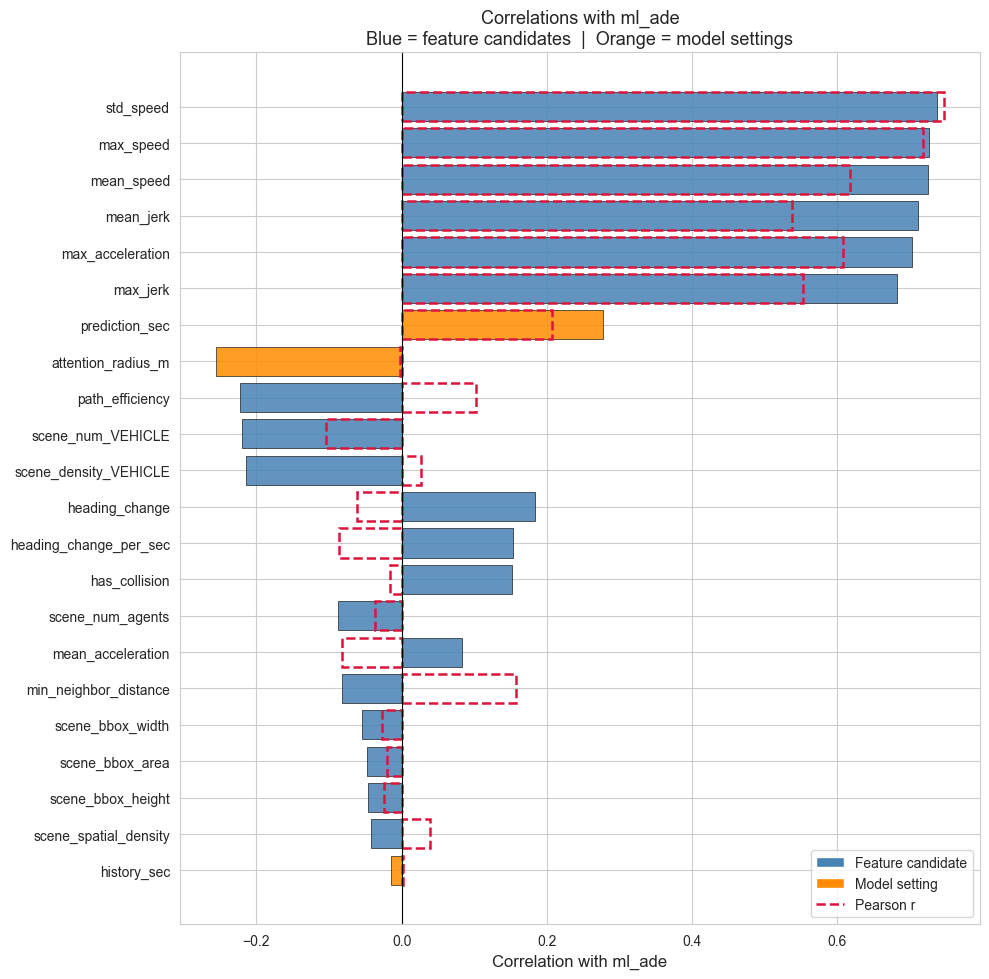


Spearman correlations with target (sorted strongest → weakest):
               Feature   Pearson  Spearman          Category
             std_speed  0.746163  0.737714 feature candidate
             max_speed  0.717344  0.725970 feature candidate
            mean_speed  0.617078  0.724032 feature candidate
             mean_jerk  0.537494  0.710622 feature candidate
      max_acceleration  0.607700  0.702041 feature candidate
              max_jerk  0.551910  0.682616 feature candidate
        prediction_sec  0.207071  0.277886     model setting
    attention_radius_m -0.002581 -0.255437     model setting
       path_efficiency  0.102368 -0.222917 feature candidate
     scene_num_VEHICLE -0.104656 -0.219426 feature candidate
 scene_density_VEHICLE  0.026859 -0.214834 feature candidate
        heading_change -0.061231  0.184193 feature candidate
heading_change_per_sec -0.086532  0.153756 feature candidate
         has_collision -0.016175  0.152489 feature candidate
      scene_num_agen

In [ ]:
# ── Feature & model-setting correlations with the target ─────────────────────
# Shows Spearman (bars) and Pearson (red dashed outline) for every feature
# candidate PLUS the 3 model settings, so you can see at a glance whether
# history/prediction horizon or attention radius matter for ADE.
# Blue = feature candidate  |  Orange = model setting (metadata)
all_for_target = numerical_cols + model_setting_cols
corr_rows = []
for c in all_for_target:
    sub = df[[c, target_col]].dropna()
    corr_rows.append(
        {
            "Feature": c,
            "Pearson": sub.corr(method="pearson").iloc[0, 1],
            "Spearman": sub.corr(method="spearman").iloc[0, 1],
            "Category": (
                "model setting" if c in model_setting_cols else "feature candidate"
            ),
        }
    )
corr_df = (
    pd.DataFrame(corr_rows)
    .sort_values("Spearman", ascending=True, key=abs)
    .reset_index(drop=True)
)

palette = {"feature candidate": "steelblue", "model setting": "darkorange"}
colors = [palette[c] for c in corr_df["Category"]]

fig, ax = plt.subplots(figsize=(10, max(7, len(all_for_target) * 0.45)))
ax.barh(
    corr_df["Feature"],
    corr_df["Spearman"],
    color=colors,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5,
    label="Spearman ρ (fill)",
)
ax.barh(
    corr_df["Feature"],
    corr_df["Pearson"],
    color="none",
    edgecolor="crimson",
    linewidth=1.8,
    linestyle="--",
    label="Pearson r (dashed outline)",
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Correlation with {target_col}", fontsize=12)
ax.set_title(
    f"Correlations with {target_col}\n"
    "Blue = feature candidates  |  Orange = model settings",
    fontsize=13,
)
from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor="steelblue", label="Feature candidate"),
    Patch(facecolor="darkorange", label="Model setting"),
    plt.Line2D(
        [0], [0], color="crimson", linewidth=1.8, linestyle="--", label="Pearson r"
    ),
]
ax.legend(handles=legend_handles, loc="lower right")
plt.tight_layout()
plt.savefig(SAVE_DIR / "target_correlations_bar.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSpearman correlations with target (sorted strongest → weakest):")
print(
    corr_df[["Feature", "Pearson", "Spearman", "Category"]]
    .sort_values("Spearman", ascending=False, key=abs)
    .to_string(index=False)
)

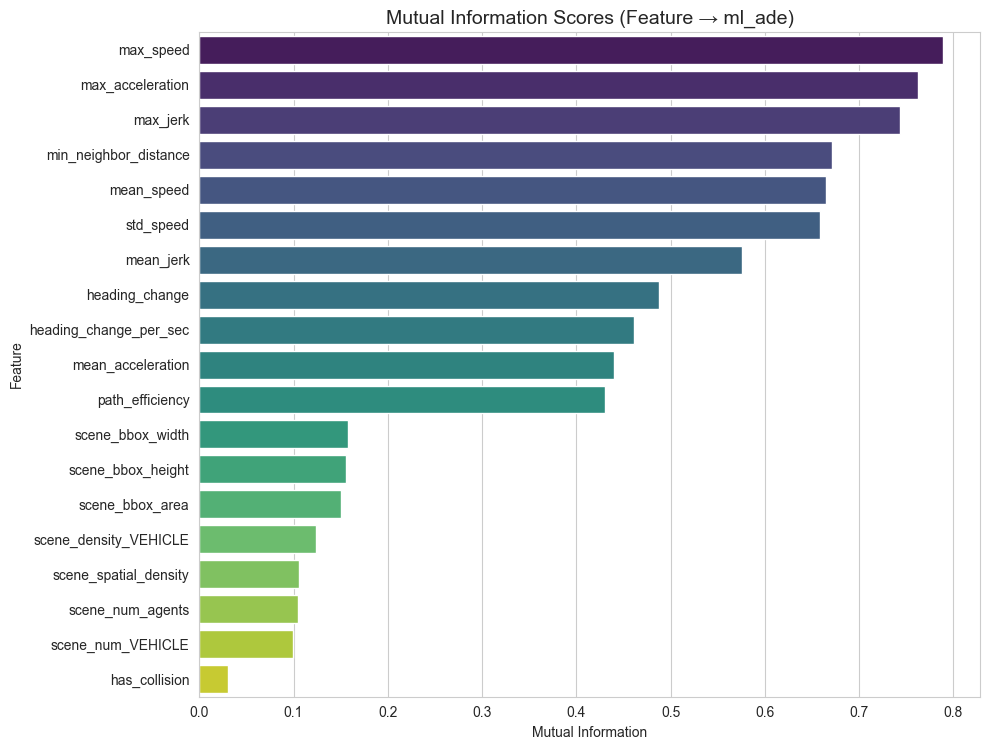

,Feature,Mutual Information
0,max_speed,0.788883
1,max_acceleration,0.763040
2,max_jerk,0.743012
3,min_neighbor_distance,0.671526
4,mean_speed,0.664742
5,std_speed,0.658368
6,mean_jerk,0.575610
7,heading_change,0.487914
8,heading_change_per_sec,0.461271
9,mean_acceleration,0.440231


In [ ]:
# Mutual Information scores (detects non-linear dependencies)
X_for_mi = df[numerical_cols].dropna()
y_for_mi = df.loc[X_for_mi.index, target_col]

mi_scores = mutual_info_regression(X_for_mi, y_for_mi, random_state=42)
mi_df = (
    pd.DataFrame({"Feature": numerical_cols, "Mutual Information": mi_scores})
    .sort_values("Mutual Information", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, max(4, len(numerical_cols) * 0.4)))
sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="viridis", ax=ax)
ax.set_title(f"Mutual Information Scores (Feature → {target_col})", fontsize=14)
plt.tight_layout()
plt.savefig(SAVE_DIR / "mutual_information_scores.png", dpi=150, bbox_inches="tight")
plt.show()

mi_df

## 6. Feature Selection: MI Elbow
**Purpose:** Remove features that are low-signal relative to the target, using a data-driven elbow on ranked MI scores rather than an arbitrary threshold.<br>
**Inputs:** `mi_df`, `numerical_cols`, and the cleaned feature matrix used for downstream modelling.<br>
**Method:** Features are ranked by Mutual Information (descending). The elbow — the point of maximum curvature on the ranked curve — separates the informative head from the low-signal tail. The elbow feature itself is the first dropped item (exclusive), following the standard scree-plot convention. VIF is computed for the surviving features and shown in the summary table.<br>
**Outputs:** `selected_features`, an elbow plot, and a summary table with MI and VIF for every candidate.<br>
**How to Verify:** confirm the elbow plot's cut-point looks sensible (clear drop in the MI curve) and that no obviously important feature is dropped.

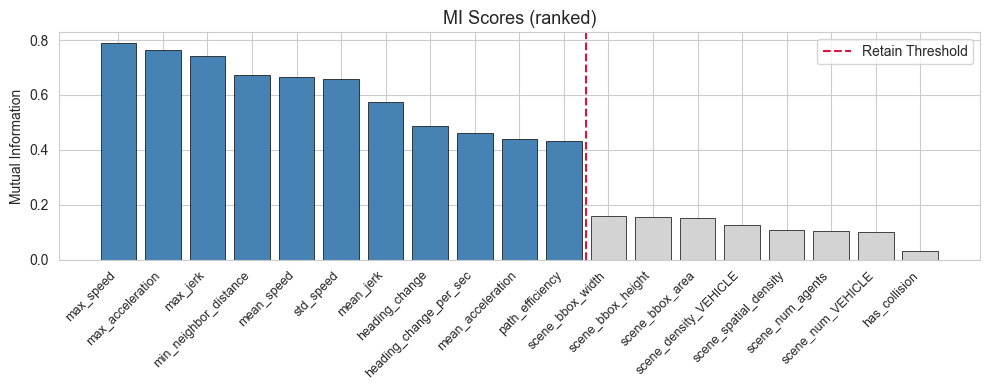

Elbow at rank 11: 'scene_bbox_width'  (MI = 0.1577)
Kept    (11): ['max_speed', 'max_acceleration', 'max_jerk', 'min_neighbor_distance', 'mean_speed', 'std_speed', 'mean_jerk', 'heading_change', 'heading_change_per_sec', 'mean_acceleration', 'path_efficiency']
Dropped (8): ['scene_bbox_width', 'scene_bbox_height', 'scene_bbox_area', 'scene_density_VEHICLE', 'scene_spatial_density', 'scene_num_agents', 'scene_num_VEHICLE', 'has_collision']

FEATURE SELECTION SUMMARY   (elbow at 'scene_bbox_width', MI = 0.1577)
  Candidates : 19
  Selected   : 11  →  ['max_speed', 'max_acceleration', 'max_jerk', 'min_neighbor_distance', 'mean_speed', 'std_speed', 'mean_jerk', 'heading_change', 'heading_change_per_sec', 'mean_acceleration', 'path_efficiency']
  Excluded   : 8


,Feature,MI score,VIF,Selected,Drop reason
0,scene_bbox_width,0.1577,—,no,Below MI elbow
1,scene_bbox_height,0.1558,—,no,Below MI elbow
2,scene_bbox_area,0.1502,—,no,Below MI elbow
3,scene_density_VEHICLE,0.1241,—,no,Below MI elbow
4,scene_spatial_density,0.1063,—,no,Below MI elbow
5,scene_num_agents,0.1043,—,no,Below MI elbow
6,scene_num_VEHICLE,0.0997,—,no,Below MI elbow
7,has_collision,0.0307,—,no,Below MI elbow
8,max_speed,0.7889,150.41,YES,
9,max_acceleration,0.7630,24.98,YES,


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Elbow detection on ranked MI scores ───────────────────────────────────────
# Find the point of maximum perpendicular distance from the line connecting the
# first and last points of the ranked MI curve. The elbow feature is the first
# dropped item (exclusive), following the standard scree-plot convention.
mi_ranked = mi_df.sort_values("Mutual Information", ascending=False).reset_index(
    drop=True
)
mi_values = mi_ranked["Mutual Information"].values


def find_elbow(values):
    n = len(values)
    if n < 3:
        return n - 1
    x = np.arange(n, dtype=float)
    y = np.array(values, dtype=float)
    x0, y0, x1, y1 = x[0], y[0], x[-1], y[-1]
    num = np.abs((y1 - y0) * x - (x1 - x0) * y + (x1 - x0) * y0 - (y1 - y0) * x0)
    den = np.sqrt((y1 - y0) ** 2 + (x1 - x0) ** 2)
    return int(np.argmax(num / den))


elbow_idx = find_elbow(mi_values)
elbow_feature = mi_ranked.iloc[elbow_idx]["Feature"]
elbow_mi = mi_values[elbow_idx]

# ── Elbow plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["steelblue" if i < elbow_idx else "lightgrey" for i in range(len(mi_values))]
ax.bar(range(len(mi_values)), mi_values, color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(
    elbow_idx - 0.5,
    color="crimson",
    linewidth=1.5,
    linestyle="--",
    label=f"Retain Threshold",
)
ax.set_xticks(range(len(mi_ranked)))
ax.set_xticklabels(mi_ranked["Feature"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Mutual Information")
ax.set_title("MI Scores (ranked)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR / "mi_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Elbow at rank {elbow_idx}: '{elbow_feature}'  (MI = {elbow_mi:.4f})")

# ── Apply elbow filter (elbow feature is excluded) ───────────────────────────
mi_lookup = dict(zip(mi_df["Feature"], mi_df["Mutual Information"]))
mi_kept = mi_ranked.iloc[:elbow_idx]["Feature"].tolist()
mi_removed = mi_ranked.iloc[elbow_idx:]["Feature"].tolist()

removal_log = [
    {
        "Removed": f,
        "Reason": "Below MI elbow",
        "MI": round(mi_lookup.get(f, 0), 4),
        "VIF": None,
    }
    for f in mi_removed
]
print(f"Kept    ({len(mi_kept)}): {mi_kept}")
print(f"Dropped ({len(mi_removed)}): {mi_removed}")


# ── VIF — informational only ──────────────────────────────────────────────────
def compute_vif(dataframe, features):
    X = dataframe[features].dropna().values
    return {features[i]: variance_inflation_factor(X, i) for i in range(len(features))}


vif_scores = compute_vif(df, mi_kept) if len(mi_kept) >= 2 else {}
selected_features = mi_kept

# ── Summary table ─────────────────────────────────────────────────────────────
removed_lookup = {e["Removed"]: e for e in removal_log}
rows = []
for f in numerical_cols:
    mi_val = mi_lookup.get(f, 0)
    selected = f in selected_features
    entry = removed_lookup.get(f, {})
    vif_val = vif_scores.get(f)
    rows.append(
        {
            "Feature": f,
            "MI score": round(mi_val, 4),
            "VIF": round(vif_val, 2) if vif_val is not None else "—",
            "Selected": "YES" if selected else "no",
            "Drop reason": "" if selected else entry.get("Reason", ""),
        }
    )

summary_df = (
    pd.DataFrame(rows)
    .sort_values(["Selected", "MI score"], ascending=[False, False])
    .reset_index(drop=True)
)

print(f"\n{'='*60}")
print(f"FEATURE SELECTION SUMMARY   (elbow at '{elbow_feature}', MI = {elbow_mi:.4f})")
print(f"{'='*60}")
print(f"  Candidates : {len(numerical_cols)}")
print(f"  Selected   : {len(selected_features)}  →  {selected_features}")
print(f"  Excluded   : {len(numerical_cols) - len(selected_features)}")
display(summary_df)

## 6.1 Multicollinearity Filter (VIF)
**Purpose:** Remove collinear features that would split SHAP attribution arbitrarily and make GAM smooth terms unidentifiable — even if each feature individually passes the MI elbow.<br>
**Inputs:** `df`, `selected_features`, `model_setting_cols`, and the selected target column.<br>
**Method:** Iterative VIF elimination. At each step, all unprotected features with VIF > 5 are identified; the one with the lowest absolute Spearman correlation with the target is dropped, keeping the most informative representative from each collinear cluster. Model settings (`attention_radius_m`, `history_sec`, `prediction_sec`) are always protected. Repeats until all remaining VIF ≤ 5.<br>
**Outputs:** updated `selected_features` with all VIF ≤ 5, a drop log, and the final VIF table.<br>
**How to Verify:** confirm all surviving features have VIF ≤ 5 and each dropped feature was genuinely collinear with a surviving one (check the drop log).

In [ ]:
# ── VIF-based multicollinearity filter ───────────────────────────────────────
# Iteratively drop the above-threshold feature with the lowest |Spearman ρ with
# target|, so the most informative representative from each collinear cluster is
# retained. Model settings are always protected.

VIF_THRESHOLD = 5.0

protected = set(model_setting_cols)
vif_candidates = list(selected_features)
vif_removal_log = []

while True:
    if len(vif_candidates) < 2:
        break
    scores = compute_vif(df, vif_candidates)
    vif_series = pd.Series(scores).sort_values(ascending=False)

    above = vif_series[
        (vif_series > VIF_THRESHOLD) & (~vif_series.index.isin(protected))
    ]
    if above.empty:
        break

    target_spearman = (
        df[above.index.tolist() + [target_col]]
        .dropna()
        .corr(method="spearman")[target_col]
        .drop(target_col)
        .abs()
    )
    drop_col = target_spearman.idxmin()
    drop_vif = round(float(vif_series[drop_col]), 1)

    vif_removal_log.append(
        {
            "Dropped": drop_col,
            "VIF at drop": drop_vif,
            "Reason": f"VIF={drop_vif}; lowest |ρ(target)|={target_spearman[drop_col]:.3f} among {len(above)} above-threshold features",
        }
    )
    print(f"Dropping '{drop_col}' (VIF={drop_vif})")
    vif_candidates.remove(drop_col)

selected_features = vif_candidates

# Final VIF table for surviving features
final_vif_df = (
    pd.Series(compute_vif(df, selected_features))
    .rename("VIF")
    .to_frame()
    .reset_index()
    .rename(columns={"index": "Feature"})
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)
final_vif_df["VIF"] = final_vif_df["VIF"].round(2)

print(f"\nVIF filter: {len(mi_kept)} → {len(selected_features)} features")
if vif_removal_log:
    print(f"\nDropped by VIF filter:")
    display(pd.DataFrame(vif_removal_log))
else:
    print("\nNo features dropped — all VIF ≤ 5.")

print(f"\nFinal features ({len(selected_features)}): {selected_features}")
print(f"\nFinal VIF (all ≤ {VIF_THRESHOLD}):")
display(final_vif_df)

## 7. Log Transform Target (If Right Skewed)
**Purpose:** Decide whether the target should be exported on a log scale and produce the final modelling table on the chosen feature/target contract.<br>
**Inputs:** target skewness estimate, selected features, and the cleaned dataframe.<br>
**Outputs:** transformed target column (when needed), final `model_df`, feature matrix/vector, and the exported prepared CSV.<br>
**How to Verify:** confirm the logged target is created only when skewness justifies it, the final row count reflects a single `dropna` after feature selection, and the exported CSV contains the expected feature plus target columns.


Target skewness: 6.3386
Apply log transformation: True


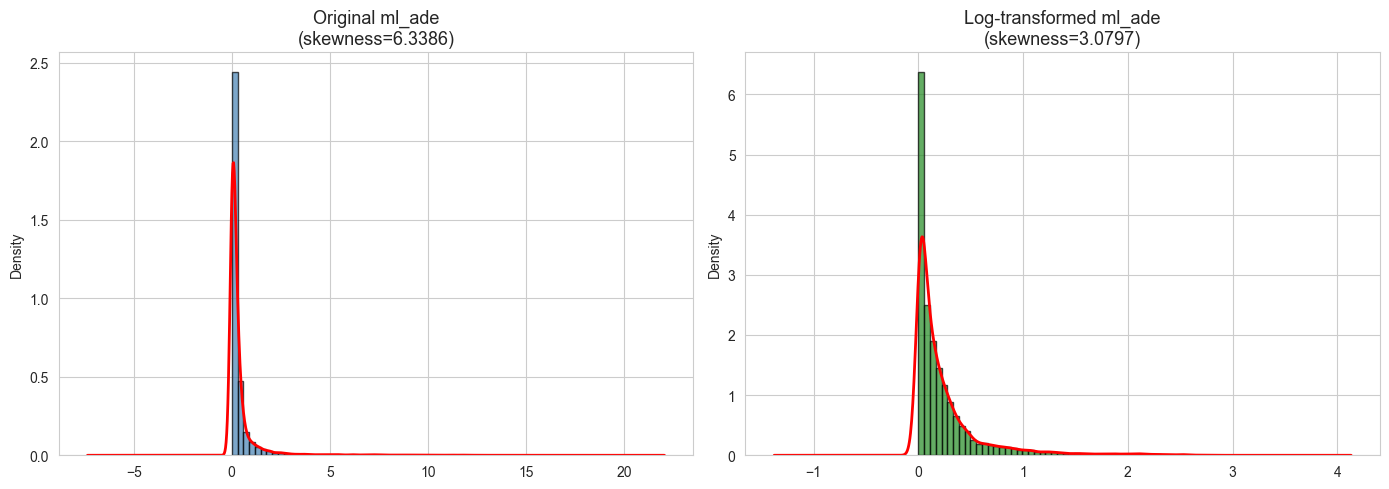


Log-transformed target column: 'ml_ade_log'


In [ ]:
# Decide on log transformation
LOG_TRANSFORM = target_skewness > 1.0
print(f"Target skewness: {target_skewness:.4f}")
print(f"Apply log transformation: {LOG_TRANSFORM}")

if LOG_TRANSFORM:
    # Keep a copy of the raw target so the before/after plots can verify that the
    # transformation improved skewness without losing access to the original values.
    y_original = df[target_col].copy()
    # Use log1p for numerical stability (handles values near zero)
    df[f"{target_col}_log"] = np.log1p(df[target_col])
    y_transformed_col = f"{target_col}_log"

    # Plot before and after
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        y_original.dropna(),
        bins=50,
        density=True,
        alpha=0.7,
        color="steelblue",
        edgecolor="black",
    )
    y_original.dropna().plot.kde(ax=axes[0], color="red", linewidth=2)
    axes[0].set_title(
        f"Original {target_col}\n(skewness={skew(y_original.dropna()):.4f})",
        fontsize=13,
    )

    y_log = df[y_transformed_col]
    axes[1].hist(
        y_log.dropna(),
        bins=50,
        density=True,
        alpha=0.7,
        color="forestgreen",
        edgecolor="black",
    )
    y_log.dropna().plot.kde(ax=axes[1], color="red", linewidth=2)
    axes[1].set_title(
        f"Log-transformed {target_col}\n(skewness={skew(y_log.dropna()):.4f})",
        fontsize=13,
    )

    plt.tight_layout()
    plt.savefig(
        SAVE_DIR / f"target_log_transform_{target_col}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

    print(f"\nLog-transformed target column: '{y_transformed_col}'")
else:
    y_transformed_col = target_col
    print("No transformation applied — target is approximately symmetric.")

In [ ]:
# Perform the final `dropna` only after feature selection and target transformation are
# fixed so the exported dataset matches the contract used by downstream modelling notebooks.
# Preserve row identity so downstream OOF, feature-effect, and metrics joins do not rely on row position.
identity_cols = [
    col for col in ["run_name", "eval_csv_name", "data_idx"] if col in df.columns
]
# Prepare the data (drop rows with NaN in selected features or target)
model_feature_cols = selected_features + [
    c for c in model_setting_feature_cols if c not in selected_features
]
export_metadata_cols = [
    c for c in model_setting_metadata_cols if c not in model_feature_cols
]
model_df = (
    df[identity_cols + model_feature_cols + export_metadata_cols + [y_transformed_col]]
    .dropna()
    .copy()
)
print(
    f"Rows available for modeling: {len(model_df)} (dropped {len(df) - len(model_df)} rows with NaN)"
)

X = model_df[model_feature_cols].values
y = model_df[y_transformed_col].values

print(f"\nModel feature columns ({len(model_feature_cols)}): {model_feature_cols}")
print(
    f"Model setting metadata columns ({len(export_metadata_cols)}): {export_metadata_cols}"
)
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

In [ ]:
# Export exactly the modelling columns that downstream notebooks will load; nothing else
# should be required for them to reconstruct the training matrix and target vector.
# Export prepared dataset into results/interpretable_model/prepared_data
EXPORT_DIR = Path("../../results/interpretable_model/prepared_data") / RUN_NAME
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_PATH = EXPORT_DIR / f"prepared_data_{target_col}.csv"
model_df.to_csv(EXPORT_PATH, index=False)
EXPORT_METADATA_PATH = EXPORT_PATH.with_suffix(".metadata.json")
EXPORT_METADATA_PATH.write_text(
    json.dumps(
        {
            "run_name": RUN_NAME,
            "eval_csv_name": EVAL_CSV_NAME,
            "target_col": target_col,
            "transformed_target_col": y_transformed_col,
            "include_model_settings_as_features": INCLUDE_MODEL_SETTINGS_AS_FEATURES,
            "model_setting_cols": model_setting_cols,
            "model_feature_cols": model_feature_cols,
            "model_setting_metadata_cols": export_metadata_cols,
        },
        indent=2,
    )
)
print(f"\nPrepared dataset (run-scoped) exported to: {EXPORT_PATH}")
print(f"Prepared dataset metadata exported to: {EXPORT_METADATA_PATH}")